# Пример использования Hyppopipe

In [2]:
from matplotlib import pyplot as plt

from hyppopipe.data.dataset import make_folder_dataset
from hyppopipe.data.torch.transforms import TorchImageTransformRecipe
from hyppopipe.common.utils import to_pyplot_image
from hyppopipe.pipeline import (
    DataLoaderStep,
    ExportCheckpointStep,
    FineTuneStep,
    Pipeline,
    PipelineContext,
)


DATASET_PATH = "/Users/nemo/Desktop/Datasets/FundusNew19022022"

Подгатавливаем преобразования для датасета (используем Fluent-интерфейс)

In [2]:
recipe = TorchImageTransformRecipe().circle_crop().rotate(90).resize((224, 224))

In [3]:
dataset = make_folder_dataset(
    root_dir=DATASET_PATH,
    train_dir="Train",
    test_dir="Validation",
    file_type="tif",
    transform_recipe=recipe,
)

In [4]:
len(dataset)

435

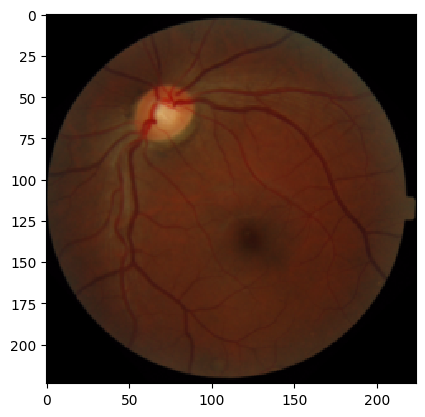

In [7]:
image, _ = dataset[11]
plt.imshow(to_pyplot_image(image), interpolation='nearest')
plt.show()

In [10]:
ctx = PipelineContext(dataset=dataset, checkpoint_path="weights.pt")
pipe = Pipeline(
    [
        ("loaders", DataLoaderStep(batch_size=16, num_workers=0)),
        (
            "finetune",
            FineTuneStep(
                backbone="resnet18",
                epochs=5,
                lr=1e-4,
                verbose=True,
            ),
        ),
        ("export", ExportCheckpointStep("weights.pt")),
    ]
)
pipe.run(ctx)

epoch 1/5 train_loss=0.2255 train_acc=0.9517 val_loss=0.0401 val_acc=1.0000
epoch 2/5 train_loss=0.0192 train_acc=1.0000 val_loss=0.0100 val_acc=1.0000
epoch 3/5 train_loss=0.0082 train_acc=1.0000 val_loss=0.0065 val_acc=1.0000
epoch 4/5 train_loss=0.0054 train_acc=1.0000 val_loss=0.0048 val_acc=1.0000
epoch 5/5 train_loss=0.0040 train_acc=1.0000 val_loss=0.0036 val_acc=1.0000


PipelineContext(dataset=<hyppopipe.data.torch.dataset.TorchImageFolderDataset object at 0x11bbdc6e0>, train_dataset=None, val_dataset=None, train_loader=<torch.utils.data.dataloader.DataLoader object at 0x124802f90>, val_loader=<torch.utils.data.dataloader.DataLoader object at 0x1247e07d0>, model=ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, mom

Веса успешно сохранились в файл. Датасет совсем небольшой - демонстрационный.

Также можно читать и dicom файлы, а также строить на их основе датасеты.

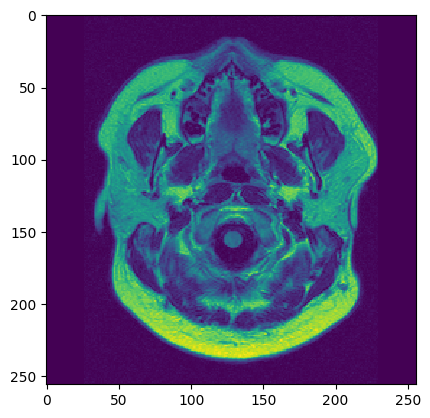

In [3]:
DICOM_PATH = "/Users/nemo/Desktop/Datasets/dicom-brain-dataset/ST000001/SE000006/IM000001.dcm"

from hyppopipe.data.image import Image
image = Image.from_path(DICOM_PATH)
plt.imshow(to_pyplot_image(image), interpolation='nearest')
plt.show()
